# 第 5 章 · 图搜索算法

在同一校园图上，用 **CodeLens 分步** 观察 BFS、DFS、UCS、Greedy、A* 的队列/栈/优先队列如何驱动搜索。

> 本 notebook 采用 [Runestone Academy · PythonDS](https://runestone.academy/ns/books/published/pythonds/index.html) 式结构：
> **Reading（阅读）→ Listing（清单/伪代码）→ ActiveCode（运行）→ CodeLens（分步状态）→ Self-Check（自测）**。
> 配套交互网页见各章 `chN.html`。

## 学习目标

- 能用邻接表表示无向加权图，并手工模拟 frontier 变化
- 能逐步执行 BFS/DFS，解释每一步 queue/stack 的内容
- 能区分「步数最少」与「代价最少」，并用 UCS/A* 验证
- 能将 Python 实现与 [ch5.html](../ch5.html) 动画逐步对应

## 1. 图与搜索问题

Runestone《Problem Solving with Algorithms and Data Structures》第 8 章从**图的基本词汇**讲起。我们把校园地图抽象为：

**顶点（vertex）** 表示地点（校门口 `x`、食堂 `s1`、操场 `c1` …）。

**边（edge）** 表示可通行的道路，附带**正整数权重**（步行分钟数）。

**搜索问题**：给定起点与目标，找一条路径。不同算法对「下一步探索谁」的规则不同——这就是本章核心。

**Listing · 搜索问题形式化**

```text
START = x
GOAL  = c1
PATH  = [v0, v1, ..., vk]  其中相邻顶点之间有边
COST(PATH) = sum(边权 along PATH)
```

**Self-Check** · 在无向图中，边 x↔s1 与 s1↔x 是否同一条路？

<details><summary>点击展开答案</summary>

是。邻接表通常双向各存一条，便于从任意端点扩展。

</details>

## 2. Listing：加载数据（ActiveCode）

### 2.1 从 JSON 读取与网页相同的图

In [1]:
# ActiveCode · 读取节点与启发式 h
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch05"))
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from IPython.display import display, Markdown
from search_algorithms import *
graph = load_graph()
start, goal = graph['start'], graph['goal']
print('起点', start, '→ 目标', goal)
display(graph_summary())

起点 x → 目标 c1


,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


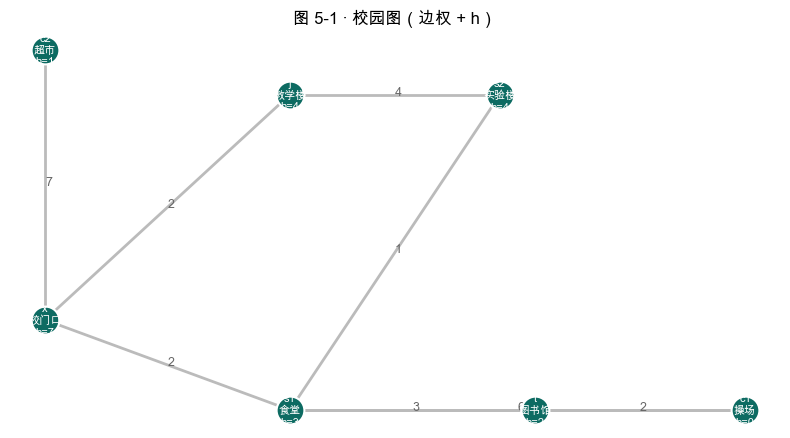

In [2]:
# ActiveCode · 边表与可视化
display(edges_table())
plot_campus(title='图 5-1 · 校园图（边权 + h）')

**Self-Check** · 从 x 出发的三个邻居是谁？按**字母序** BFS 入队顺序是什么？

*运行下一 ActiveCode 前请先预测。*

<details><summary>点击展开答案</summary>

邻居 c2, j, s1（字母序）。BFS 第一层入队顺序即 c2 → j → s1。

</details>

In [3]:
# ActiveCode · x 的邻居与 h
display(neighbors_table('x'))

,邻居,边代价,h
0,c2,7,1
1,j,2,4
2,s1,2,3


## 3. Listing + CodeLens：构建邻接表

PythonDS 先教 **Graph ADT**，再教 BFS。我们逐条边把 JSON 写入 `adj`，每写一条就打印当前邻接表——等价于 Runestone 的 CodeLens 观察引用结构如何生长。

**Listing · 邻接表构建（核心循环）**

```text
adj = {}
for edge in edges:
    a, b, cost = edge['from'], edge['to'], edge['cost']
    adj.setdefault(a, []).append((b, cost))
    adj.setdefault(b, []).append((a, cost))
    sort each adjacency list by neighbor id
```

In [4]:
# ActiveCode · CodeLens · 邻接表构建（首尾帧）
frames_adj = codelens_build_adjacency()
print(f'共 {len(frames_adj)-1} 条边，{len(frames_adj)} 个 CodeLens 帧')
print_codelens(frames_adj, limit=4)
print('…')
print_codelens(frames_adj[-2:])

共 8 条边，9 个 CodeLens 帧
── Step 0 ── 初始化空邻接表
   执行: adj = {}
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('s2', 4), ('x', 2)], 's1': [('c1', 6), ('s2', 1), ('t', 3), ('x', 2)], 's2': [('j', 4), ('s1', 1)], 't': [('c1', 2), ('s1', 3)], 'c1': [('s1', 6), ('t', 2)]}
   已处理边 = 0

── Step 1 ── 第 1 条边写入邻接表
   执行: 添加 x↔c2 cost=7
   adj = {'x': [('c2', 7)], 'c2': [('x', 7)]}
   边 = 'x↔c2'
   代价 = 7

── Step 2 ── 第 2 条边写入邻接表
   执行: 添加 x↔j cost=2
   adj = {'x': [('c2', 7), ('j', 2)], 'c2': [('x', 7)], 'j': [('x', 2)]}
   边 = 'x↔j'
   代价 = 2

── Step 3 ── 第 3 条边写入邻接表
   执行: 添加 x↔s1 cost=2
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('x', 2)], 's1': [('x', 2)]}
   边 = 'x↔s1'
   代价 = 2

…
── Step 7 ── 第 7 条边写入邻接表
   执行: 添加 s1↔c1 cost=6
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('s2', 4), ('x', 2)], 's1': [('c1', 6), ('s2', 1), ('t', 3), ('x', 2)], 's2': [('j', 4), ('s1', 1)], 't': [('s1', 3)], 'c1': [('s1', 6)]}


In [5]:
# ActiveCode · 验证最终 adj
adj = build_adjacency(graph['edges'])
print('完整 adj[x] =', adj['x'])

完整 adj[x] = [('c2', 7), ('j', 2), ('s1', 2)]


## 4. 广度优先搜索 BFS

### 4.1 Reading：队列与层序

BFS 用 **FIFO 队列**。从起点开始，每次弹出**队头**，把未访问邻居加到**队尾**。在**等权图**上，BFS 第一次到达目标时步数最少。

**Listing · BFS 伪代码（PythonDS 风格）**

```text
function BFS(start, goal):
    frontier ← Queue([start])
    visited ← {}
    parent ← {}
    while frontier not empty:
        current ← frontier.dequeue()
        if current == goal: return path(parent, goal)
        for each neighbor n of current:
            if n not visited and n not in frontier:
                parent[n] ← current
                frontier.enqueue(n)
        mark current visited
```

**Self-Check** · 下一步弹出队头时，frontier 第一个元素是谁？（从 x 开始第一轮扩展后）

<details><summary>点击展开答案</summary>

c2（字母序：c2, j, s1 入队后，队头是 c2）。

</details>

### 4.2 CodeLens · BFS 完整逐步执行

In [6]:
# ActiveCode · 生成全部 BFS 帧
bfs_frames = codelens_bfs()
print(f'BFS 共 {len(bfs_frames)} 个 CodeLens 帧')

BFS 共 14 个 CodeLens 帧


In [7]:
# ActiveCode · CodeLens · BFS 第 1–8 帧
print_codelens(bfs_frames, limit=8)

── Step 0 ── BFS 初始化：队列仅含起点
   执行: frontier = [start]
   frontier = ['x']
   visited = set()
   parent = {}

── Step 1 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # x
   current = 'x'
   frontier = []
   visited = {'x'}
   到达目标? = False

── Step 1 ── 扩展邻居 c2
   执行: frontier.append(c2)  # 经 x 来，边权 7
   扩展 = 'c2'
   经 = 'x'
   frontier = ['c2']
   parent = {'c2': 'x'}

── Step 1 ── 扩展邻居 j
   执行: frontier.append(j)  # 经 x 来，边权 2
   扩展 = 'j'
   经 = 'x'
   frontier = ['c2', 'j']
   parent = {'c2': 'x', 'j': 'x'}

── Step 1 ── 扩展邻居 s1
   执行: frontier.append(s1)  # 经 x 来，边权 2
   扩展 = 's1'
   经 = 'x'
   frontier = ['c2', 'j', 's1']
   parent = {'c2': 'x', 'j': 'x', 's1': 'x'}

── Step 2 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # c2
   current = 'c2'
   frontier = ['j', 's1']
   visited = {'c2', 'x'}
   到达目标? = False

── Step 3 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # j
   current = 'j'
   frontier = ['s1']
   visited = {'j', 'c2', 'x'}
   到达目标? = False

── St

In [8]:
# ActiveCode · CodeLens · BFS 剩余帧
print_codelens(bfs_frames[8:])

── Step 4 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # s1
   current = 's1'
   frontier = ['s2']
   visited = {'j', 's1', 'c2', 'x'}
   到达目标? = False

── Step 4 ── 扩展邻居 c1
   执行: frontier.append(c1)  # 经 s1 来，边权 6
   扩展 = 'c1'
   经 = 's1'
   frontier = ['s2', 'c1']
   parent = {'c2': 'x', 'j': 'x', 's1': 'x', 's2': 'j', 'c1': 's1'}

── Step 4 ── 扩展邻居 t
   执行: frontier.append(t)  # 经 s1 来，边权 3
   扩展 = 't'
   经 = 's1'
   frontier = ['s2', 'c1', 't']
   parent = {'c2': 'x', 'j': 'x', 's1': 'x', 's2': 'j', 'c1': 's1', 't': 's1'}

── Step 5 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # s2
   current = 's2'
   frontier = ['c1', 't']
   visited = {'s2', 'x', 's1', 'c2', 'j'}
   到达目标? = False

── Step 6 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # c1
   current = 'c1'
   frontier = ['t']
   visited = {'s2', 'x', 's1', 'c1', 'c2', 'j'}
   到达目标? = True

── Step 7 ── 发现目标，沿 parent 回溯路径
   执行: break
   path = ['x', 's1', 'c1']
   步数 = 2
   代价 = 8



,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,j→s1,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s1,2,3,s2,c2→j→s1→x,False
4,5,s2,6,4,c1→t,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


最终路径: x→s1→c1
代价: 8


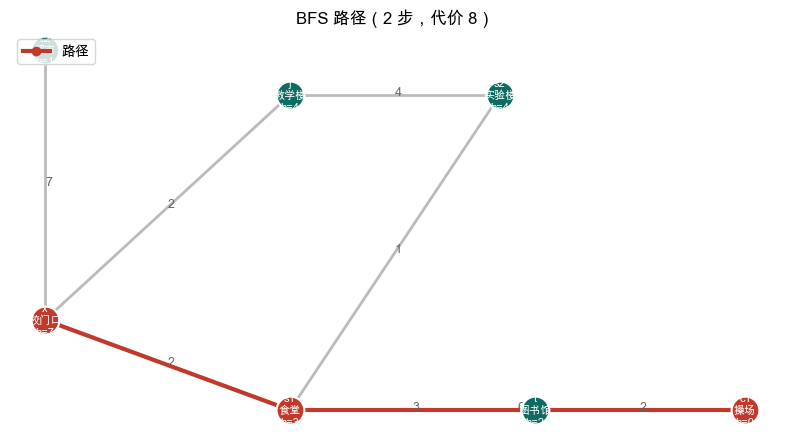

In [9]:
# ActiveCode · 汇总表 + 路径图
display(trace_search('bfs'))
path_bfs = run_all()['bfs']['path']
print('最终路径:', '→'.join(path_bfs))
print('代价:', path_cost(path_bfs, adj))
plot_campus(path_bfs, title='BFS 路径（2 步，代价 8）')

**Self-Check** · BFS 2 步到达，但代价 8 不是最低——为什么？

<details><summary>点击展开答案</summary>

BFS 优化的是**边数（步数）**，不是**边权之和**。本图边权不同，需 UCS/A*。

</details>

## 5. 深度优先搜索 DFS

### 5.1 Reading：栈与回溯

DFS 用 **LIFO 栈**。邻居按**逆字母序**入栈时，会先深入 `j → s2 → s1`，再到达 `c1`。路径更长、代价更高，但仍能找到目标。

**Listing · DFS 伪代码**

```text
function DFS(start, goal):
    stack ← [start]
    while stack not empty:
        current ← stack.pop()
        if current visited: continue
        mark visited
        if current == goal: return path
        for neighbor in reverse(sorted(neighbors(current))):
            stack.push(neighbor)
```

In [10]:
# ActiveCode · CodeLens · DFS 前 10 帧
dfs_frames = codelens_dfs()
print_codelens(dfs_frames, limit=10)

── Step 0 ── DFS 初始化
   执行: stack=[start]
   stack = ['x']
   visited = set()

── Step 1 ── 栈顶弹出
   执行: current = stack.pop()  # x
   current = 'x'
   stack = []
   visited = {'x'}

── Step 1 ── 逆序入栈邻居 s1 (cost=2)
   执行: stack.append(s1)
   stack = ['s1']
   parent = {'s1': 'x'}

── Step 1 ── 逆序入栈邻居 j (cost=2)
   执行: stack.append(j)
   stack = ['s1', 'j']
   parent = {'s1': 'x', 'j': 'x'}

── Step 1 ── 逆序入栈邻居 c2 (cost=7)
   执行: stack.append(c2)
   stack = ['s1', 'j', 'c2']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x'}

── Step 2 ── 栈顶弹出
   执行: current = stack.pop()  # c2
   current = 'c2'
   stack = ['s1', 'j']
   visited = {'c2', 'x'}

── Step 3 ── 栈顶弹出
   执行: current = stack.pop()  # j
   current = 'j'
   stack = ['s1']
   visited = {'j', 'c2', 'x'}

── Step 3 ── 逆序入栈邻居 s2 (cost=4)
   执行: stack.append(s2)
   stack = ['s1', 's2']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x', 's2': 'j'}

── Step 4 ── 栈顶弹出
   执行: current = stack.pop()  # s2
   current = 's2'
   stack = ['s1']
   visited =

── Step 5 ── 逆序入栈邻居 t (cost=3)
   执行: stack.append(t)
   stack = ['t']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x', 's2': 'j', 't': 's1'}

── Step 5 ── 逆序入栈邻居 c1 (cost=6)
   执行: stack.append(c1)
   stack = ['t', 'c1']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x', 's2': 'j', 't': 's1', 'c1': 's1'}

── Step 6 ── 栈顶弹出
   执行: current = stack.pop()  # c1
   current = 'c1'
   stack = ['t']
   visited = {'s2', 'x', 's1', 'c1', 'c2', 'j'}

── Step 6 ── 到达目标
   执行: break
   path = ['x', 's1', 'c1']
   代价 = 8



,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,s1→j,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s2,6,4,s1,c2→j→s2→x,False
4,5,s1,2,3,∅,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


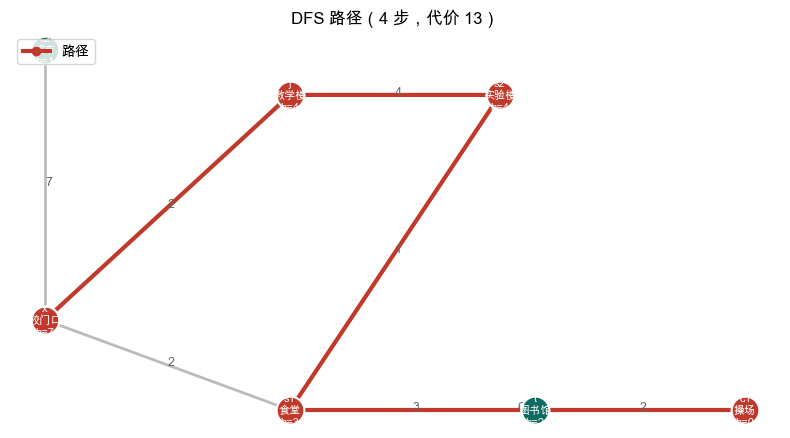

In [11]:
# ActiveCode · DFS 剩余帧与结果
print_codelens(dfs_frames[10:])
display(trace_search('dfs'))
plot_campus(run_all()['dfs']['path'], title='DFS 路径（4 步，代价 13）')

## 6. 一致代价搜索 UCS

UCS 使用**优先队列**，键为 **g(n)**——从起点到 n 的累计代价。每次弹出 g 最小的节点。本例最优路径 `x→s1→t→c1`，代价 **7**。

**Listing · UCS 键函数**

```text
priority = g(n)  # 累计边权
```

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,j,2,4,s1→c2,j→x,False
2,3,s1,2,3,s2→c2,j→s1→x,False
3,4,s2,3,4,t→c2→c1,j→s1→s2→x,False
4,5,t,5,2,c2→c1,j→s1→s2→t→x,False
5,6,c1,7,0,c2,c1→j→s1→s2→t→x,True


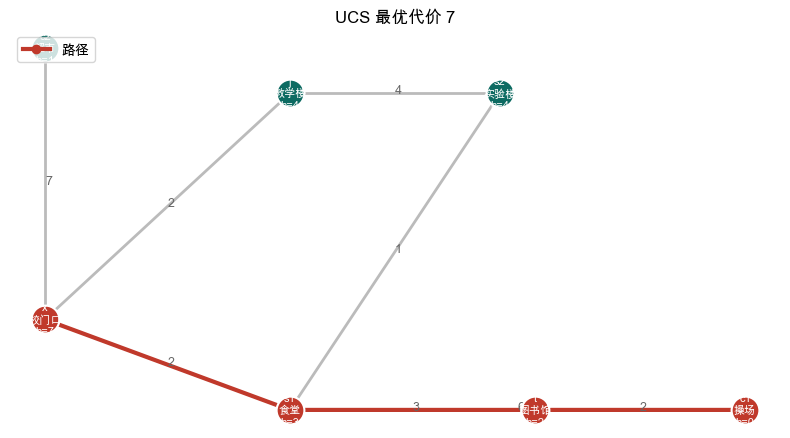

In [12]:
# ActiveCode · UCS trace
display(trace_search('ucs'))
plot_campus(run_all()['ucs']['path'], title='UCS 最优代价 7')

## 7. Greedy 与 A*

**Greedy** 按 **h(n)** 排序（估计到目标的距离）。**A*** 按 **f(n)=g(n)+h(n)**。从 x 出发第一步：超市 c2 的 f=7+1=8，食堂 s1 的 f=2+3=5，故 A* 先展开 s1。

**Listing · A* 评估**

```text
f(n) = g(n) + h(n)
```

In [13]:
# ActiveCode · x 处各邻居 g、h、f 明细
display(first_step_scores())

,邻居,g,h,f=g+h,名称
2,s1,2,3,5,食堂
1,j,2,4,6,教学楼
0,c2,7,1,8,超市


In [14]:
# ActiveCode · Greedy 与 A* 逐步 trace
display(trace_search('greedy'))
display(trace_search('astar'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,s1→j,c2→x,False
2,3,s1,2,3,j,c2→s1→x,False
3,4,c1,8,0,t→j→s2,c1→c2→s1→x,True


,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,s1,2,3,j→c2,s1→x,False
2,3,j,2,4,t→s2→c1→c2,j→s1→x,False
3,4,t,5,2,s2→c1→c2,j→s1→t→x,False
4,5,c1,7,0,s2→c2,c1→j→s1→t→x,True


## 8. 五种算法对照

,算法,路径,步数,代价,与网页
0,DFS,x→j→s2→s1→c1,4,13,✓
1,BFS,x→s1→c1,2,8,✓
2,UCS,x→s1→t→c1,3,7,✓
3,Greedy,x→s1→c1,2,8,✓
4,A*,x→s1→t→c1,3,7,✓


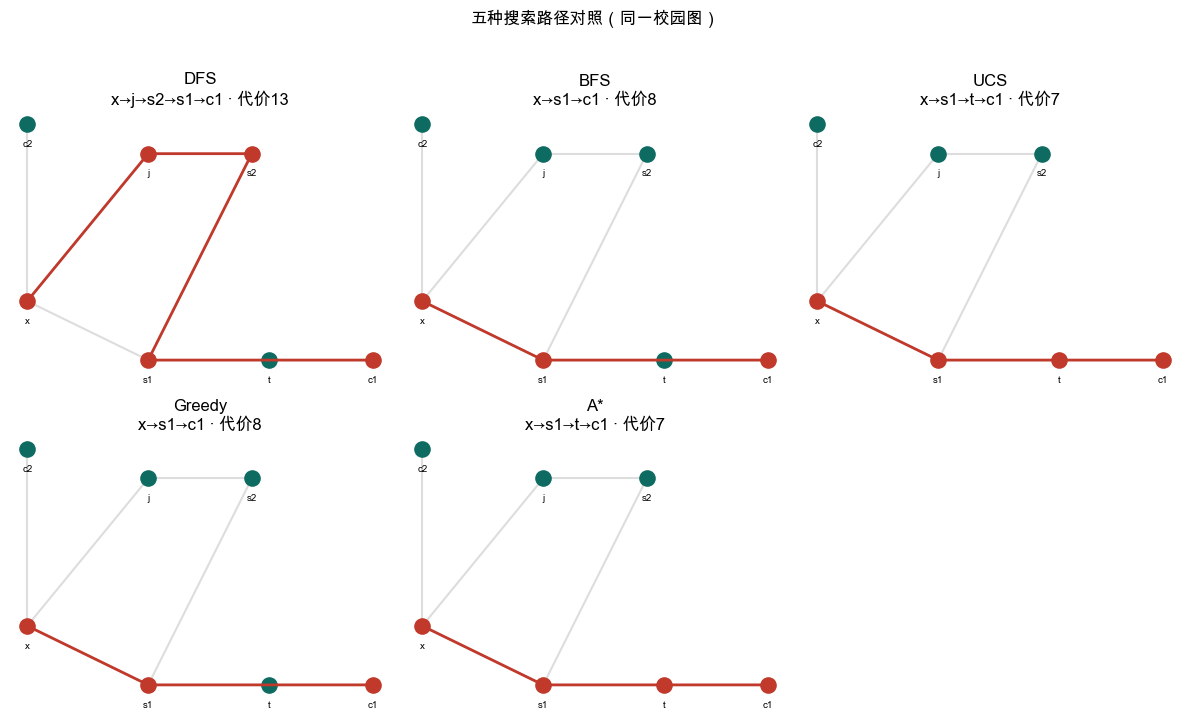

✓ 五种算法路径与 ch5.html 完全一致


In [15]:
# ActiveCode · 与 ch5.html 交叉验证
display(comparison_table())
plot_all_paths()
verify_against_web()

## 本章小结

**队列 BFS** 保证最少步数；**栈 DFS** 不保证最优；**UCS/A*** 在加权图上 pursuit 最低代价。

Runestone 强调边读边运行——本 notebook 用 CodeLens 帧展示**每一步**的 frontier/stack 与 parent。

回到 [ch5.html](../ch5.html) 实验室，对照动画逐步预测下一帧。

## 练习题

1. 若所有边权改为 1，BFS 与 UCS 路径是否相同？用代码修改 `edges` 后验证。
2. 把 DFS 入栈顺序改为正字母序，路径如何变化？
3. 解释 MiniMax（网页第 6 种）与 campus 单智能体搜索的本质区别。